In [1]:
%load_ext autoreload
%autoreload 2
#
import warnings
warnings.filterwarnings('ignore')
#
import numpy as np
np.set_printoptions(legacy='1.25')
import pandas as pd
import os
import torch
import random
from tqdm.notebook import tqdm
import itertools
from itertools import product
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from PIL import Image, ImageDraw, ImageFont
import pytorch_lightning as pl
from torch.nn import functional as F
import pyrootutils
#
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from transformers import AutoProcessor, Gemma3ForConditionalGeneration
from qwen_vl_utils import process_vision_info

In [2]:
# This notebook can be run end-to-end in a few minutes. 
# Remove the guards to replicate experiments entirely.

# UTILS

In [3]:
STENCIL_SIZE = 50
CANVAS_SIZE = [900,900]
spritesheet = np.load('stencils.npy')
SHAPES = {'triangle':spritesheet[9],'heart':spritesheet[96],'star':spritesheet[98],'square':spritesheet[-1]}
target_x = spritesheet[24]
fixed_shapes = ['square','triangle','heart','star']
d1,d2 = 25,875
fixed_coords = np.array([[d1,d1],[d1,d2],[d2,d1],[d2,d2]])

In [4]:
#Generate non-overlapping positions for all objects
def generate_positions_partial(fixed_objects,canvas_size,stencil_size) -> np.ndarray:
    # Calculate valid position range
    margin = stencil_size // 2
    min_x = margin
    max_x = canvas_size[0] - margin
    min_y = margin
    max_y = canvas_size[1] - margin
    
    # Pre-allocate positions array
    fixed_objects = fixed_objects
    
    # Generate valid position
    while True:
        pos = np.random.randint([min_x, min_y], [max_x, max_y], size=2)
            
        # Check distance from all previous objects
        distances = np.linalg.norm(fixed_objects - pos, axis=1)
        if np.all(distances >= stencil_size):#5 buffer
            positions = np.vstack([pos,fixed_objects])
            break
            
    return positions,np.linalg.norm(positions - positions[0], axis=1)

In [5]:
#place stencil on canvas
def add_stencil(canvas,stencil,color,x,y,background_color='white'):
    colored_shape = color_shape(stencil, color,background_color)  # Returns (3, H, W)
    shape_pil = Image.fromarray(colored_shape.transpose(1, 2, 0))
    if shape_pil.size != (STENCIL_SIZE, STENCIL_SIZE):
        shape_pil = shape_pil.resize((STENCIL_SIZE, STENCIL_SIZE))
    paste_x = int(x - STENCIL_SIZE // 2)
    paste_y = int(y - STENCIL_SIZE // 2)
    canvas.paste(shape_pil, (paste_x, paste_y))

In [6]:
#transform stencil color-shape
def color_shape(img: np.ndarray,stencil_color,background_color='white') -> np.ndarray:
    ''' Colors a grayscale numpy array with a red background and black shape. '''
    fg_col = np.array(mcolors.to_rgb(stencil_color)).astype(np.float32)
    bg_col = np.array(mcolors.to_rgb(background_color)).astype(np.float32)
    img = img.astype(np.float32) / 255  # Normalize grayscale
    colored = bg_col.reshape(3, 1, 1) + (fg_col.reshape(3, 1, 1) - bg_col.reshape(3, 1, 1)) * (1 - img)
    return (255 * colored).astype(np.uint8)

# Dataset

In [7]:
STENCIL_POSITION_DATASET = 'stencil_position_dataset/'
os.makedirs(STENCIL_POSITION_DATASET, exist_ok=True)

In [8]:
# Creates a dataframe with the description/metadata of images

columns = ['ID','target_shape','target_X','target_Y'] + [f'D{str(i).zfill(2)}_{attr}' 
                                            for i in range(3) for attr in ['X', 'Y', 'SHAPE', 'DIST']]
metadata = pd.DataFrame(columns=columns)
for run in range(1000):
    #get shapes, positions, distances
    positions,distances = generate_positions_partial(fixed_coords,CANVAS_SIZE,STENCIL_SIZE)
    shuffled_shapes = random.sample(fixed_shapes, len(fixed_shapes))
    #marshall row
    row = {'ID':str(len(metadata)).zfill(4),'target_shape':'x',
           'target_X':positions[0][0],'target_Y':positions[0][1]}
    row.update({f'D{str(i).zfill(2)}_SHAPE':shuffled_shapes[i] for i in range(4)})
    row.update({f'D{str(i).zfill(2)}_X':(positions)[i+1][0] for i in range(4)})
    row.update({f'D{str(i).zfill(2)}_Y':(positions)[i+1][1] for i in range(4)})
    row.update({f'D{str(i).zfill(2)}_DIST':(distances)[i+1] for i in range(4)})
    metadata = pd.concat([metadata, pd.DataFrame([row])], ignore_index=True)

In [9]:
print(metadata.iloc[0].dropna())

ID                    0000
target_shape             x
target_X               244
target_Y               367
D00_X                   25
D00_Y                   25
D00_SHAPE           square
D00_DIST        406.109591
D01_X                   25
D01_Y                  875
D01_SHAPE            heart
D01_DIST        553.195264
D02_X                  875
D02_Y                   25
D02_SHAPE             star
D02_DIST        717.722091
D03_SHAPE         triangle
D03_X                875.0
D03_Y                875.0
D03_DIST        810.077157
Name: 0, dtype: object


In [10]:
def make_image_4stencils(instructions):
    canvas = Image.new('RGB', CANVAS_SIZE, 'white')
    add_stencil(canvas,target_x,'red',instructions['target_X'],instructions['target_Y'])
    for elem in range(4):
        prefix = 'D'+str(elem).zfill(2)   
        add_stencil(canvas,SHAPES[instructions[prefix+'_SHAPE']],'black',instructions[prefix+'_X'],
                    instructions[prefix+'_Y'])
    return canvas

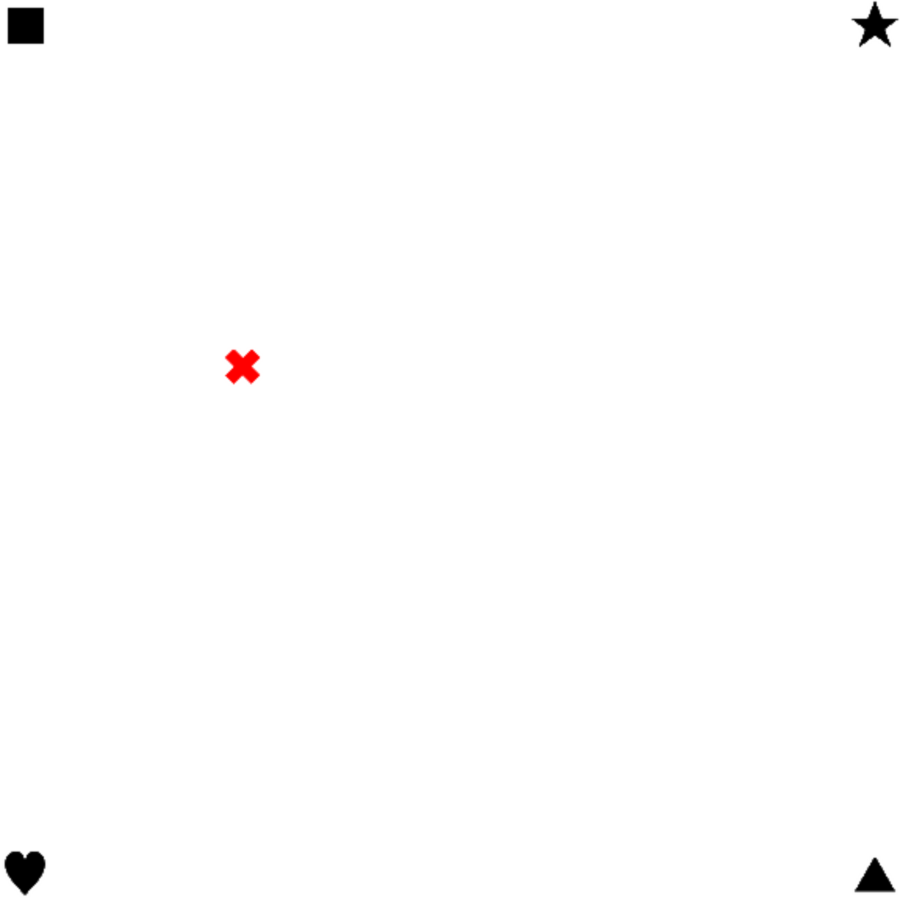

In [11]:
make_image_4stencils(metadata.iloc[0])

In [12]:
#transform each metadata row into one image
for i in range(metadata.shape[0]):
    instructions = metadata.iloc[i]
    canvas = make_image_4stencils(instructions)
    canvas.save(STENCIL_POSITION_DATASET+instructions['ID']+'.png')

# QWEN

In [13]:
def get_qwen():
    qwen_model = Qwen2_5_VLForConditionalGeneration.from_pretrained('Qwen/Qwen2.5-VL-7B-Instruct', 
                                                                torch_dtype='auto', device_map='auto')
    qwen_processor = AutoProcessor.from_pretrained('Qwen/Qwen2.5-VL-7B-Instruct') 
    qwen_vocab = qwen_processor.tokenizer.get_vocab()
    return qwen_model,qwen_processor,qwen_vocab

In [14]:
def get_qwen_inputs(model,processor,img_path,query_string):
    batch_messages = [[{'role': 'system', 'content': 'You are a helpful assistant.'}, 
      {'role': 'user', 'content': [{'type': 'image', 'image': 'file://'+img_path}, 
        {'type': 'text', 'text': query_string}]}]]    
    texts = [
            processor.apply_chat_template(
                msg,
                tokenize=False,
                add_generation_prompt=True
            ) for msg in batch_messages
        ]
    image_inputs, video_inputs = process_vision_info(batch_messages)
    inputs = processor(
            text=texts,
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors='pt'
        ).to(model.device)
    return inputs

In [15]:
def ask_qwen(model,processor,vocab,img_path,query):
    inputs = get_qwen_inputs(model,processor,img_path,query)
    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=128,
                return_dict_in_generate=True, output_scores=True)       
    num_system_tokens = 14
    num_image_tokens = 326  # 18 x 18 + 2 (start, end image token)
    num_user_tokens = inputs.input_ids.shape[1] - num_system_tokens - num_image_tokens
    str_out = processor.decode(output.sequences[0][num_system_tokens+num_image_tokens+num_user_tokens:-1])
    scores = output['scores'][0][0]
    return {'Q':query,'A':str_out,'scores':scores}

In [16]:
def find_value_qwen(dictionary,answer):
    candidates = [answer,answer.lower(),answer.capitalize(),answer.upper()]
    candidates = candidates + ['Ġ'+x for x in candidates] + ['ġ'+x for x in candidates]
    candidates = candidates + [x[:-1] for x in candidates] + [x[:-2] for x in candidates] + \
                                [x[:-3] for x in candidates] + [x[:-4] for x in candidates]
    for key in candidates:
        if key in dictionary:
            return dictionary[key]  # Return value as soon as a match is found
    return "----------------------------------"+answer  # No match found

In [17]:
qwen_model,qwen_processor,qwen_vocab = get_qwen()

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [18]:
qwen_results = metadata.copy()
qwen_results['answer']=None
for s in fixed_shapes:
    qwen_results[s]=None

In [19]:
query = "The picture contains four black shapes: a square, triangle, heart and a star. "+\
            "There is also a red X. Which black shape is the closest to the X? Respond with only the shape's name.\n"

for i, row in qwen_results.iterrows():
    if i==5:#GUARD
        break#remove this guard to run over all images
    img_path = STENCIL_POSITION_DATASET+(str(int(row['ID'])).zfill(4))+'.png'
    response = ask_qwen(qwen_model,qwen_processor,qwen_vocab,img_path,query)
    answer = response['A'].lower().strip()
    if len(answer.split()) > 1 or answer not in fixed_shapes:
        print('PROBLEM!'+str(row['ID'])+'--->'+answer)
    qwen_results.loc[i,'answer']=answer
    for s in fixed_shapes:
        qwen_results.loc[i,s]=response['scores'][find_value_qwen(qwen_vocab,s)].item()
    qwen_results.loc[i,answer]=response['scores'][find_value_qwen(qwen_vocab,response['A'])].item()

In [20]:
qwen_results

,ID,target_shape,target_X,target_Y,D00_X,D00_Y,D00_SHAPE,D00_DIST,D01_X,D01_Y,...,D02_DIST,D03_SHAPE,D03_X,D03_Y,D03_DIST,answer,square,triangle,heart,star
0,0000,x,244,367,25,25,square,406.109591,25,875,...,717.722091,triangle,875.0,875.0,810.077157,heart,14125000.0,15750000.0,21500000.0,15312500.0
1,0001,x,227,584,25,25,star,594.377826,25,875,...,855.794952,triangle,875.0,875.0,710.341467,heart,14625000.0,16125000.0,21500000.0,15000000.0
2,0002,x,805,349,25,25,square,844.615889,25,875,...,331.475489,heart,875.0,875.0,530.637353,heart,12812500.0,15250000.0,21750000.0,15812500.0
3,0003,x,603,326,25,25,heart,651.678602,25,875,...,405.690769,star,875.0,875.0,612.686706,triangle,14562500.0,21250000.0,15812500.0,16250000.0
4,0004,x,352,86,25,25,triangle,332.640948,25,875,...,526.545345,heart,875.0,875.0,946.599176,triangle,14062500.0,21750000.0,14312500.0,15875000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0995,x,253,86,25,25,triangle,236.019067,25,875,...,624.984000,star,875.0,875.0,1004.691495,None,None,None,None,None
996,0996,x,801,415,25,25,heart,868.490645,25,875,...,396.958436,triangle,875.0,875.0,465.914155,None,None,None,None,None
997,0997,x,635,54,25,25,square,610.688955,25,875,...,241.745734,heart,875.0,875.0,855.360158,None,None,None,None,None
998,0998,x,36,372,25,25,triangle,347.174308,25,875,...,907.926208,square,875.0,875.0,978.227990,None,None,None,None,None


In [21]:
print(qwen_results.iloc[0].dropna())

ID                    0000
target_shape             x
target_X               244
target_Y               367
D00_X                   25
D00_Y                   25
D00_SHAPE           square
D00_DIST        406.109591
D01_X                   25
D01_Y                  875
D01_SHAPE            heart
D01_DIST        553.195264
D02_X                  875
D02_Y                   25
D02_SHAPE             star
D02_DIST        717.722091
D03_SHAPE         triangle
D03_X                875.0
D03_Y                875.0
D03_DIST        810.077157
answer               heart
square          14125000.0
triangle        15750000.0
heart           21500000.0
star            15312500.0
Name: 0, dtype: object


# Gemma

In [22]:
def get_gemma():
    model_id = "google/gemma-3-12b-it"    
    gemma_model = Gemma3ForConditionalGeneration.from_pretrained(
        model_id, device_map="auto"
    ).eval()    
    gemma_processor = AutoProcessor.from_pretrained(model_id)
    gemma_vocab = gemma_processor.tokenizer.get_vocab()
    return gemma_model,gemma_processor,gemma_vocab

In [23]:
def get_gemma_inputs(model,processor,img_path,query_string):
    messages = [{"role": "system","content": [{"type": "text", "text": "You are a helpful assistant."}]},
    {"role": "user","content": [{"type": "image", "image": img_path},{"type": "text", "text": query_string}]}]
    inputs = processor.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors="pt"
    ).to(model.device, dtype=torch.bfloat16)
    return inputs

In [24]:
def ask_gemma(model,processor,vocab,img_path,query):
    inputs = get_gemma_inputs(model,processor,img_path,query)
    input_len = inputs["input_ids"].shape[-1]
    with torch.inference_mode():
        generation = model.generate(**inputs, max_new_tokens=100, do_sample=False,
                return_dict_in_generate=True, output_scores=True)
    str_out = processor.decode(generation['sequences'][0][input_len:-1])
    scores = generation['scores'][0][0]
    return {'Q':query,'A':str_out,'scores':scores}

In [25]:
def find_value_gemma(dictionary,answer):
    candidates = [answer,answer.lower(),answer.capitalize(),answer.upper()]
    candidates = candidates + ['▁'+x for x in candidates]
    candidates = candidates + [x[:-1] for x in candidates] + [x[:-2] for x in candidates] + \
                                [x[:-3] for x in candidates] + [x[:-4] for x in candidates]
    for key in candidates:
        if key in dictionary:
            return dictionary[key]  # Return value as soon as a match is found
    return "----------------------------------"+answer  # No match found

In [26]:
gemma_model,gemma_processor,gemma_vocab = get_gemma()

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

In [27]:
gemma_results = metadata.copy()
gemma_results['answer']=None
for s in fixed_shapes:
    gemma_results[s]=None

In [28]:
query = "The picture contains four black shapes: a square, triangle, heart and a star. "+\
            "There is also a red X. Which black shape is the closest to the X? Respond with only the shape's name.\n"

for i, row in gemma_results.iterrows():
    if i==5:#GUARD
        break#remove this guard to run over all images
    img_path = STENCIL_POSITION_DATASET+(str(int(row['ID'])).zfill(4))+'.png'
    response = ask_gemma(gemma_model,gemma_processor,gemma_vocab,img_path,query)
    answer = response['A'].lower().strip()
    if len(answer.split()) > 1 or answer not in fixed_shapes:
        print('PROBLEM!'+str(row['ID'])+'--->'+answer)
    gemma_results.loc[i,'answer']=answer
    for s in fixed_shapes:
        gemma_results.loc[i,s]=response['scores'][find_value_gemma(gemma_vocab,s)].item()
    gemma_results.loc[i,answer]=response['scores'][find_value_gemma(gemma_vocab,response['A'])].item()

In [29]:
gemma_results

,ID,target_shape,target_X,target_Y,D00_X,D00_Y,D00_SHAPE,D00_DIST,D01_X,D01_Y,...,D02_DIST,D03_SHAPE,D03_X,D03_Y,D03_DIST,answer,square,triangle,heart,star
0,0000,x,244,367,25,25,square,406.109591,25,875,...,717.722091,triangle,875.0,875.0,810.077157,heart,25.125,29.25,46.75,22.875
1,0001,x,227,584,25,25,star,594.377826,25,875,...,855.794952,triangle,875.0,875.0,710.341467,heart,19.375,25.5,43.25,20.375
2,0002,x,805,349,25,25,square,844.615889,25,875,...,331.475489,heart,875.0,875.0,530.637353,heart,27.75,34.75,53.5,36.0
3,0003,x,603,326,25,25,heart,651.678602,25,875,...,405.690769,star,875.0,875.0,612.686706,triangle,39.5,56.5,38.0,39.25
4,0004,x,352,86,25,25,triangle,332.640948,25,875,...,526.545345,heart,875.0,875.0,946.599176,triangle,30.375,49.25,28.125,23.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0995,x,253,86,25,25,triangle,236.019067,25,875,...,624.984000,star,875.0,875.0,1004.691495,None,None,None,None,None
996,0996,x,801,415,25,25,heart,868.490645,25,875,...,396.958436,triangle,875.0,875.0,465.914155,None,None,None,None,None
997,0997,x,635,54,25,25,square,610.688955,25,875,...,241.745734,heart,875.0,875.0,855.360158,None,None,None,None,None
998,0998,x,36,372,25,25,triangle,347.174308,25,875,...,907.926208,square,875.0,875.0,978.227990,None,None,None,None,None


In [30]:
print(gemma_results.iloc[0].dropna())

ID                    0000
target_shape             x
target_X               244
target_Y               367
D00_X                   25
D00_Y                   25
D00_SHAPE           square
D00_DIST        406.109591
D01_X                   25
D01_Y                  875
D01_SHAPE            heart
D01_DIST        553.195264
D02_X                  875
D02_Y                   25
D02_SHAPE             star
D02_DIST        717.722091
D03_SHAPE         triangle
D03_X                875.0
D03_Y                875.0
D03_DIST        810.077157
answer               heart
square              25.125
triangle             29.25
heart                46.75
star                22.875
Name: 0, dtype: object
